In [ ]:
!pip install vizdoom
!pip -q install imageio

In [ ]:
"""
PPO (Proximal Policy Optimization) for VizDoom
PPO by Schulman et al.(2017)
Code by: Puneet Sharma and Claude Code is used to debug the errors
"""

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from collections import deque
from PIL import Image
import vizdoom as vzd
import csv

# Save the same metrics permanently in a CSV file.
HISTORY_PATH = "ppo_training_history.csv"

# --------------------------------------------------------------------------- #
# Hyperparameters
# --------------------------------------------------------------------------- #
SCENARIO = "basic"
TOTAL_STEPS = 200000        # total env steps summed over all actors (paper: 10M steps = 40M frames)

HORIZON = 512       # steps collected before each PPO update which happens at TOTAL_STEPS/HORIZON x No of actors
N_ACTORS = 4                # Parallel actors
EPOCHS_PER_UPDATE = 3       # K: epochs (Atari)
BATCH_SIZE = 32 * 8         # minibatch size (Atari: 32 * 8 actors = 256)

LR = 2.5e-4                 # Adam stepsize
CLIP_EPS = 0.2              # epsilon
GAMMA = 0.99
GAE_LAMBDA = 0.95
VF_COEF = 0.5               # Arbitrary
ENT_COEF = 0.01             # c2 (Atari)

FRAME_STACK = 4
FRAME_SKIP = 4
IMG_SIZE = 128               # I use 128 arbitrarily for VizDoom
RGB_CHANNELS = 3


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH = "./ppo_vizdoom_simple.pt"

# This is important to stabalize the training
REWARD_SCALE = 0.01



# Environment
class VizDoomEnv:
    """Minimal wrapper: RGB-> resize -> stack N frames."""

    def __init__(self, scenario, verbose=False):
        cfg = scenario if scenario.endswith(".cfg") else f"{scenario}.cfg"
        if not os.path.isfile(cfg):
            cfg = os.path.join(vzd.scenarios_path, cfg)

        self.game = vzd.DoomGame()
        self.game.load_config(cfg)
        self.game.set_window_visible(False)
        self.game.set_screen_format(vzd.ScreenFormat.RGB24)
        self.game.set_screen_resolution(vzd.ScreenResolution.RES_320X240)
        self.game.init()
        if verbose:
            print("Buttons available in this scenario:", self.game.get_available_buttons())


        self.n_actions = self.game.get_available_buttons_size()
        self.actions = np.eye(self.n_actions, dtype=int).tolist() # one hot encoding
        self.frames = deque(maxlen=FRAME_STACK) # double queue  to remember the last few frames for game-play


    def _frame(self):
        """Return one normalized RGB frame with shape (3, IMG_SIZE, IMG_SIZE)."""

        img = self.game.get_state().screen_buffer

        # Some VizDoom versions return RGB as (3, H, W).
        # Pillow requires RGB as (H, W, 3).
        if img.ndim == 3 and img.shape[0] == 3:
            img = np.transpose(img, (1, 2, 0))


        img = Image.fromarray(img).convert("RGB")
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        img = np.asarray(img, dtype=np.uint8)          # keep 0-255

        return np.transpose(img, (2, 0, 1))            # (C, H, W)




    def reset(self):
        self.game.new_episode()

        frame = self._frame()

        # Remove frames from the preceding episode.
        self.frames.clear()

        # At the start, repeat the first RGB frame four times.
        self.frames.extend([frame] * FRAME_STACK)

        # (4 frames, 3 channels, 128, 128) -> (12, 128, 128)
        return np.concatenate(self.frames, axis=0)


    def step(self, action):
        # method executes an action in the game and returns the reward
        # counts agent steps, not frames which can be more if they are skipped
        reward = self.game.make_action(
            self.actions[action],
            FRAME_SKIP
        )

        done = self.game.is_episode_finished()

        frame = self.frames[-1] if done else self._frame()
        self.frames.append(frame)

        # Return four RGB frames as 12 CNN channels.
        return np.concatenate(self.frames, axis=0), reward, done



# Actor-Critic network, This is different than the original implementation
class ActorCritic(nn.Module):
    def __init__(self, in_channels, n_actions):
        super().__init__()
        # 3 Conv layers
        self.body = nn.Sequential(
          nn.Conv2d(in_channels, 32, kernel_size=8, stride=4),
          nn.ReLU(),
          nn.Conv2d(32, 64, kernel_size=4, stride=2),
          nn.ReLU(),
          nn.Conv2d(64, 64, kernel_size=3, stride=1),
          nn.ReLU(),
          nn.Flatten(),
        )
        with torch.no_grad():
            # Creates a fake batch containing input images
            n_features = self.body(torch.zeros(1, in_channels, IMG_SIZE, IMG_SIZE)).shape[1]
        self.hidden = nn.Sequential(nn.Linear(n_features, 256), nn.ReLU())
        # the three CNN layers extract an embedding from the inputs
        # the embedding is mapped to actor->action logits and critic's value estimate
        self.actor = nn.Linear(256, n_actions)
        self.critic = nn.Linear(256, 1)


    def forward(self, x):
        x = x.float() / 255.0                      # uint8 -> [0, 1]
        h = self.hidden(self.body(x))
        return self.actor(h), self.critic(h).squeeze(-1)

    #  used for choosing a new action
    def act(self, x):
        logits, value = self.forward(x)
        # categorical probability distribution over discrete actions.
        dist = Categorical(logits=logits)
        # Samples an action according to the policy distribution.
        action = dist.sample()
        return action, dist.log_prob(action), value
    #score an action that was already chosen
    def evaluate(self, x, action):
        logits, value = self.forward(x)
        dist = Categorical(logits=logits)
        return dist.log_prob(action), dist.entropy(), value


# Generalized Advantage Estimation
def compute_gae(rewards, values, dones, last_value):
    advantages = torch.zeros_like(rewards)
    gae = torch.zeros_like(last_value)
    values = torch.cat([values, last_value.unsqueeze(0)], dim=0)
    # process the rollout backwards
    for t in reversed(range(rewards.shape[0])):
        nonterminal = 1.0 - dones[t]
        # TD error
        delta = rewards[t] + GAMMA * values[t + 1] * nonterminal - values[t]
        # Compute the GAE advantage recursively
        gae = delta + GAMMA * GAE_LAMBDA * nonterminal * gae
        advantages[t] = gae
    returns = advantages + values[:-1]
    return advantages, returns

# Training method
def train_method():
    envs = [VizDoomEnv(SCENARIO, verbose=(i == 0)) for i in range(N_ACTORS)]
    n_actions = envs[0].n_actions
    # 4 x 3 = 12 (if 4 Frames)
    in_channels = FRAME_STACK * RGB_CHANNELS

    agent = ActorCritic(in_channels, n_actions).to(device)
    optimizer = optim.Adam(agent.parameters(), lr=LR)

    obs = np.stack([e.reset() for e in envs])          # (N, C, H, W) uint8
    ep_reward = np.zeros(N_ACTORS)
    ep_steps = np.zeros(N_ACTORS, dtype=int)
    episode_rewards = deque(maxlen=20)
    episode_lengths = deque(maxlen=20)
    step_count = 0

    with open(HISTORY_PATH, mode="w", newline="") as f:
        csv.writer(f).writerow([
            "step", "mean_reward", "mean_episode_length",
            "policy_loss", "value_loss", "entropy", "kl",
        ])

    while step_count < TOTAL_STEPS:
        # Linear annealing of learning rate and clip epsilon (alpha: 1 -> 0)
        alpha = max(1.0 - step_count / TOTAL_STEPS, 0.0)
        for g in optimizer.param_groups:
            g["lr"] = LR * alpha
        clip_eps = CLIP_EPS * alpha

        # ---- each of N actors runs the policy for T timesteps ---- #
        obs_buf = torch.zeros((HORIZON, N_ACTORS, in_channels, IMG_SIZE, IMG_SIZE),
                              dtype=torch.uint8, device=device)
        act_buf = torch.zeros((HORIZON, N_ACTORS), dtype=torch.long, device=device)
        logp_buf = torch.zeros((HORIZON, N_ACTORS), device=device)
        rew_buf = torch.zeros((HORIZON, N_ACTORS), device=device)
        done_buf = torch.zeros((HORIZON, N_ACTORS), device=device)
        val_buf = torch.zeros((HORIZON, N_ACTORS), device=device)

        for t in range(HORIZON):
            obs_t = torch.from_numpy(obs).to(device)
            with torch.no_grad():
                action, log_prob, value = agent.act(obs_t)
            actions = action.cpu().numpy()

            rewards = np.zeros(N_ACTORS, dtype=np.float32)
            dones = np.zeros(N_ACTORS, dtype=np.float32)
            next_obs = np.empty_like(obs)

            for i, env in enumerate(envs):
                o, r, d = env.step(int(actions[i]))
                rewards[i], dones[i] = r, float(d)
                ep_reward[i] += r
                ep_steps[i] += 1
                if d:
                    episode_rewards.append(ep_reward[i])
                    episode_lengths.append(ep_steps[i])
                    ep_reward[i], ep_steps[i] = 0.0, 0
                    o = env.reset()
                next_obs[i] = o

            obs_buf[t] = obs_t
            act_buf[t] = action
            logp_buf[t] = log_prob
            # Scale the reward stored for training.
            rew_buf[t] = torch.from_numpy(rewards * REWARD_SCALE).to(device)
            done_buf[t] = torch.from_numpy(dones).to(device)
            val_buf[t] = value
            obs = next_obs
            step_count += N_ACTORS

        with torch.no_grad():
            _, last_value = agent.forward(torch.from_numpy(obs).to(device))

        # ---- advantage estimates ---- #
        advantages, returns = compute_gae(rew_buf, val_buf, done_buf, last_value)
        # ---- flatten the batch ---- #
        b_obs = obs_buf.reshape(-1, in_channels, IMG_SIZE, IMG_SIZE)
        b_act = act_buf.reshape(-1)
        b_logp = logp_buf.reshape(-1)
        b_adv = advantages.reshape(-1)
        b_ret = returns.reshape(-1)
        n = b_obs.shape[0]
        pl_list, vl_list, ent_list, kl_list = [], [], [], []

        # ---- K epochs of minibatch on L = L_CLIP - c1*L_VF + c2*S ---- eq 9 from paper#
        for epoch in range(EPOCHS_PER_UPDATE):
            idx = torch.randperm(n, device=device)
            for start in range(0, n, BATCH_SIZE):
                mb = idx[start:start + BATCH_SIZE]
                new_logp, entropy, new_value = agent.evaluate(b_obs[mb], b_act[mb])
                ratio = (new_logp - b_logp[mb]).exp()

                # normalize advantages per minibatch
                mb_adv = b_adv[mb]
                mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)

                surr1 = ratio * mb_adv
                surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * mb_adv
                policy_loss = -torch.min(surr1, surr2).mean()
                value_loss = (new_value - b_ret[mb]).pow(2).mean()   # plain squared error
                entropy_mean = entropy.mean()
                loss = policy_loss + VF_COEF * value_loss - ENT_COEF * entropy_mean
                optimizer.zero_grad()
                loss.backward()
                # rescales all gradients together if their combined norm exceeds 0.5,
                nn.utils.clip_grad_norm_(agent.parameters(), 0.5)
                optimizer.step()

                with torch.no_grad():
                    approx_kl = (b_logp[mb] - new_logp).mean().item()
                pl_list.append(policy_loss.item())
                vl_list.append(value_loss.item())
                ent_list.append(entropy_mean.item())
                kl_list.append(approx_kl)

        mean_reward = np.mean(episode_rewards) if episode_rewards else float("nan")
        mean_length = np.mean(episode_lengths) if episode_lengths else float("nan")
        mean_pl, mean_vl = np.mean(pl_list), np.mean(vl_list)
        mean_ent, mean_kl = np.mean(ent_list), np.mean(kl_list)

        with open(HISTORY_PATH, mode="a", newline="") as f:
            csv.writer(f).writerow([
                step_count, mean_reward, mean_length,
                mean_pl, mean_vl, mean_ent, mean_kl,
            ])

        print(f"step={step_count}/{TOTAL_STEPS}  mean_reward={mean_reward:.2f}  "
              f"mean_ep_len={mean_length:.1f}  policy_loss={mean_pl:.4f}  "
              f"value_loss={mean_vl:.4f}  entropy={mean_ent:.3f}  kl={mean_kl:.4f}  ")

    torch.save(agent.state_dict(), SAVE_PATH)
    print(f"Saved model to {SAVE_PATH}")
    for e in envs:
        e.game.close()


train_method()

Buttons available in this scenario: [<Button.MOVE_LEFT: 11>, <Button.MOVE_RIGHT: 10>, <Button.ATTACK: 0>]
step=2048/200000  mean_reward=-152.15  mean_ep_len=43.0  policy_loss=-0.0033  value_loss=0.2357  entropy=1.094  kl=0.0077  
step=4096/200000  mean_reward=-202.60  mean_ep_len=50.0  policy_loss=0.0002  value_loss=0.2918  entropy=1.091  kl=0.0001  
step=6144/200000  mean_reward=-157.55  mean_ep_len=42.9  policy_loss=-0.0034  value_loss=0.3941  entropy=1.063  kl=0.0035  
step=8192/200000  mean_reward=-171.70  mean_ep_len=45.5  policy_loss=-0.0022  value_loss=0.4510  entropy=1.078  kl=0.0065  
step=10240/200000  mean_reward=-236.50  mean_ep_len=56.0  policy_loss=0.0011  value_loss=0.3994  entropy=1.083  kl=-0.0000  
step=12288/200000  mean_reward=-135.80  mean_ep_len=41.6  policy_loss=-0.0030  value_loss=0.5561  entropy=1.087  kl=0.0094  
step=14336/200000  mean_reward=-239.15  mean_ep_len=55.9  policy_loss=-0.0026  value_loss=0.4132  entropy=1.071  kl=0.0047  
step=16384/200000  mean_

,step,mean_reward,mean_episode_length,policy_loss,value_loss,entropy,kl
0,2048,-152.15,43.00,-0.003350,0.235718,1.094114,0.007739
1,4096,-202.60,49.95,0.000183,0.291814,1.090567,0.000077
2,6144,-157.55,42.90,-0.003377,0.394085,1.062967,0.003470
3,8192,-171.70,45.45,-0.002191,0.450983,1.077760,0.006487
4,10240,-236.50,55.95,0.001133,0.399376,1.082718,-0.000013


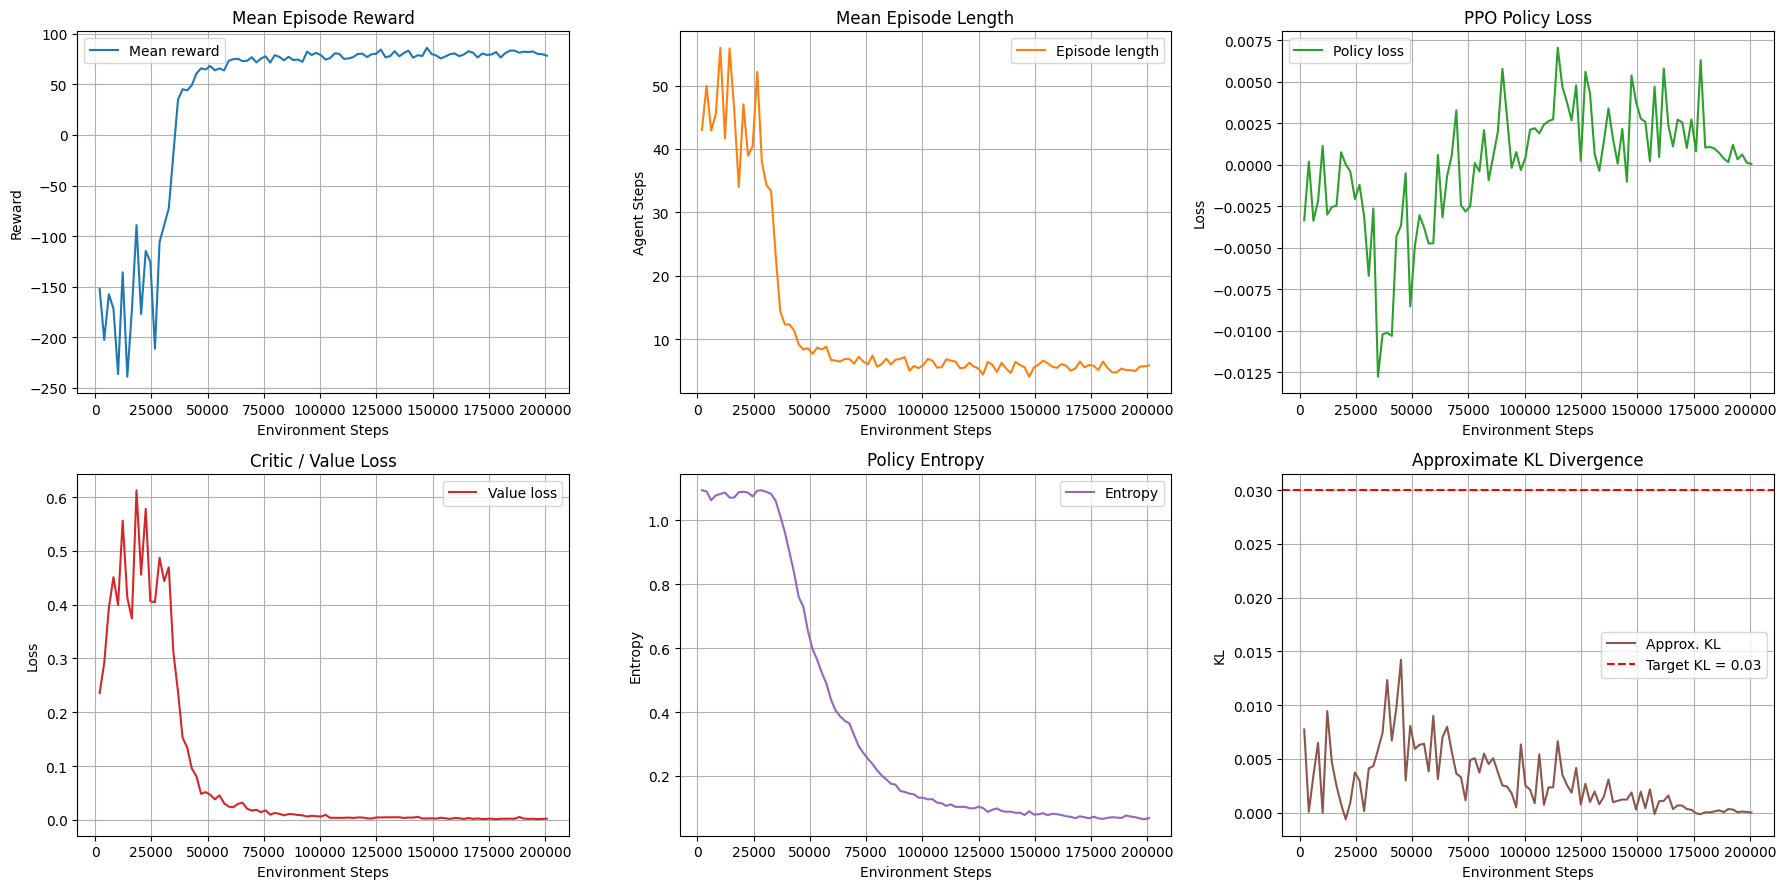

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file created during training.
HISTORY_PATH = "ppo_training_history.csv"
df = pd.read_csv(HISTORY_PATH)

# Inspect the first few saved PPO updates.
display(df.head())

# Create six metric plots.
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# --------------------------------------------------------------------------- #
# 1. Mean reward
# --------------------------------------------------------------------------- #
axes[0, 0].plot(
    df["step"],
    df["mean_reward"],
    color="tab:blue",
    label="Mean reward",
)
axes[0, 0].set_title("Mean Episode Reward")
axes[0, 0].set_xlabel("Environment Steps")
axes[0, 0].set_ylabel("Reward")
axes[0, 0].grid(True)
axes[0, 0].legend()

# --------------------------------------------------------------------------- #
# 2. Mean episode length
# --------------------------------------------------------------------------- #
axes[0, 1].plot(
    df["step"],
    df["mean_episode_length"],
    color="tab:orange",
    label="Episode length",
)
axes[0, 1].set_title("Mean Episode Length")
axes[0, 1].set_xlabel("Environment Steps")
axes[0, 1].set_ylabel("Agent Steps")
axes[0, 1].grid(True)
axes[0, 1].legend()

# --------------------------------------------------------------------------- #
# 3. PPO policy loss
# --------------------------------------------------------------------------- #
axes[0, 2].plot(
    df["step"],
    df["policy_loss"],
    color="tab:green",
    label="Policy loss",
)
axes[0, 2].set_title("PPO Policy Loss")
axes[0, 2].set_xlabel("Environment Steps")
axes[0, 2].set_ylabel("Loss")
axes[0, 2].grid(True)
axes[0, 2].legend()

# --------------------------------------------------------------------------- #
# 4. Critic/value loss
# --------------------------------------------------------------------------- #
axes[1, 0].plot(
    df["step"],
    df["value_loss"],
    color="tab:red",
    label="Value loss",
)
axes[1, 0].set_title("Critic / Value Loss")
axes[1, 0].set_xlabel("Environment Steps")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].grid(True)
axes[1, 0].legend()

# --------------------------------------------------------------------------- #
# 5. Policy entropy
# --------------------------------------------------------------------------- #
axes[1, 1].plot(
    df["step"],
    df["entropy"],
    color="tab:purple",
    label="Entropy",
)
axes[1, 1].set_title("Policy Entropy")
axes[1, 1].set_xlabel("Environment Steps")
axes[1, 1].set_ylabel("Entropy")
axes[1, 1].grid(True)
axes[1, 1].legend()

# --------------------------------------------------------------------------- #
# 6. Approximate KL divergence
# --------------------------------------------------------------------------- #
axes[1, 2].plot(
    df["step"],
    df["kl"],
    color="tab:brown",
    label="Approx. KL",
)

# Optional: show your PPO early-stopping threshold.
TARGET_KL = 0.03

axes[1, 2].axhline(
    TARGET_KL,
    color="red",
    linestyle="--",
    label=f"Target KL = {TARGET_KL}",
)

axes[1, 2].set_title("Approximate KL Divergence")
axes[1, 2].set_xlabel("Environment Steps")
axes[1, 2].set_ylabel("KL")
axes[1, 2].grid(True)
axes[1, 2].legend()

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import torch
import imageio.v2 as imageio

from PIL import Image
from IPython.display import display, Image as DisplayImage
from torch.distributions import Categorical


def play_and_visualize_colab(
    model_path="./ppo_vizdoom_simple.pt",
    scenario="basic",
    num_episodes=5,
    max_steps=500,
    fps=10,
    deterministic=True,
):
    """
    Load an RGB-input PPO model, play VizDoom episodes headlessly,
    save color GIFs, and display them in Google Colab.

    The model expects:
        FRAME_STACK * RGB_CHANNELS channels
        e.g. 4 RGB frames -> 12 channels.
    """

    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"Checkpoint not found: {model_path}\n"
            "Check that training completed and the file path is correct."
        )

    # The environment must be the same RGB VizDoomEnv used in training.
    env = VizDoomEnv(scenario)

    # Your RGB model receives:
    # FRAME_STACK * RGB_CHANNELS = 4 * 3 = 12 input channels.
    agent = ActorCritic(
        in_channels=FRAME_STACK * RGB_CHANNELS,
        n_actions=env.n_actions,
    ).to(device)

    # Load trained parameters.
    checkpoint = torch.load(model_path, map_location=device)
    agent.load_state_dict(checkpoint)
    agent.eval()

    print(f"Loaded model from: {model_path}")
    print(f"Using device: {device}")
    print(f"Model input channels: {FRAME_STACK * RGB_CHANNELS}")
    print(f"Playing {num_episodes} episode(s)...\n")

    episode_results = []

    try:
        for episode in range(1, num_episodes + 1):
            obs = env.reset()

            done = False
            total_reward = 0.0
            step_count = 0
            frames = []

            while not done and step_count < max_steps:
                # ----------------------------------------------------------- #
                # Capture the original VizDoom RGB screen for a color GIF.
                # ----------------------------------------------------------- #
                state = env.game.get_state()

                if state is not None:
                    frame = state.screen_buffer

                    # VizDoom RGB24 may return channel-first:
                    # (3, height, width).
                    #
                    # Pillow/imageio require channel-last:
                    # (height, width, 3).
                    if frame.ndim == 3 and frame.shape[0] == 3:
                        frame = np.transpose(frame, (1, 2, 0))

                    # Ensure RGB, then optionally enlarge for easier viewing.
                    frame = Image.fromarray(frame).convert("RGB")
                    frame = frame.resize((640, 480), Image.NEAREST)

                    frames.append(np.asarray(frame))

                # ----------------------------------------------------------- #
                # Ask the PPO policy for the next action.
                #
                # obs shape: (12, 128, 128)
                # obs_t shape: (1, 12, 128, 128)
                # ----------------------------------------------------------- #
                obs_t = torch.tensor(
                    obs,
                    dtype=torch.float32,
                    device=device,
                ).unsqueeze(0)

                with torch.no_grad():
                    logits, _ = agent(obs_t)

                    if deterministic:
                        # Pick the action with highest predicted probability.
                        action = torch.argmax(logits, dim=1).item()
                    else:
                        # Sample an action from the learned distribution.
                        distribution = Categorical(logits=logits)
                        action = distribution.sample().item()

                obs, reward, done = env.step(action)

                total_reward += reward
                step_count += 1

            # Save the episode as a color GIF.
            gif_path = f"vizdoom_episode_{episode:02d}.gif"

            if frames:
                imageio.mimsave(
                    gif_path,
                    frames,
                    fps=fps,
                    loop=0,
                )

            print(
                f"Episode {episode}: "
                f"reward={total_reward:.2f}, "
                f"agent_steps={step_count}, "
                f"saved={gif_path}"
            )

            # Display GIF directly in the Colab output cell.
            if frames:
                display(DisplayImage(filename=gif_path))

            episode_results.append({
                "episode": episode,
                "reward": total_reward,
                "steps": step_count,
                "gif_path": gif_path,
            })

    finally:
        env.game.close()

    return episode_results

Loaded model from: ./ppo_vizdoom_simple.pt
Using device: cuda
Model input channels: 12
Playing 10 episode(s)...

Episode 1: reward=87.00, agent_steps=4, saved=vizdoom_episode_01.gif


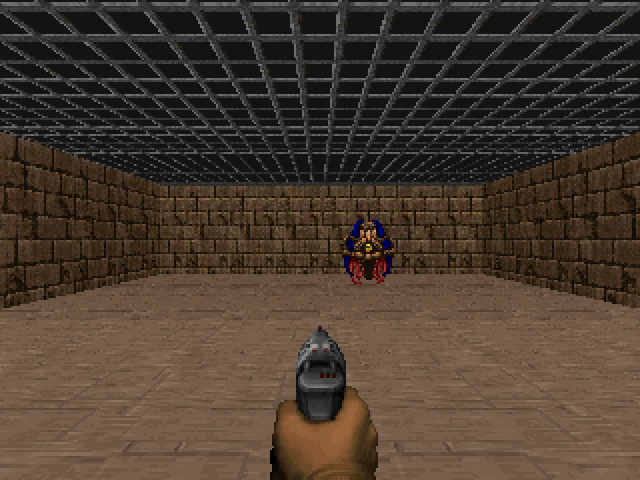

Episode 2: reward=95.00, agent_steps=2, saved=vizdoom_episode_02.gif


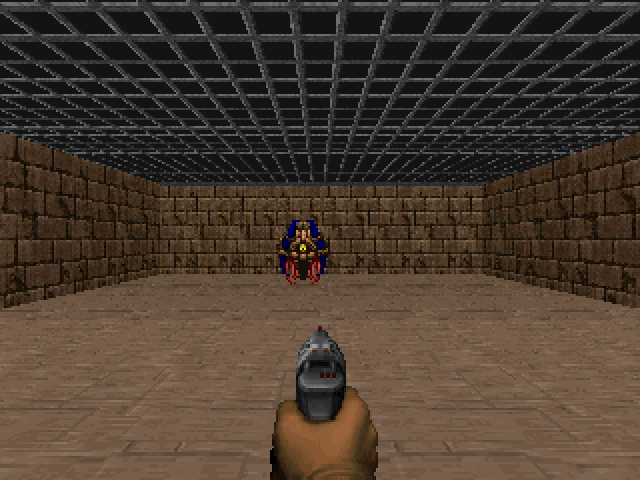

Episode 3: reward=95.00, agent_steps=2, saved=vizdoom_episode_03.gif


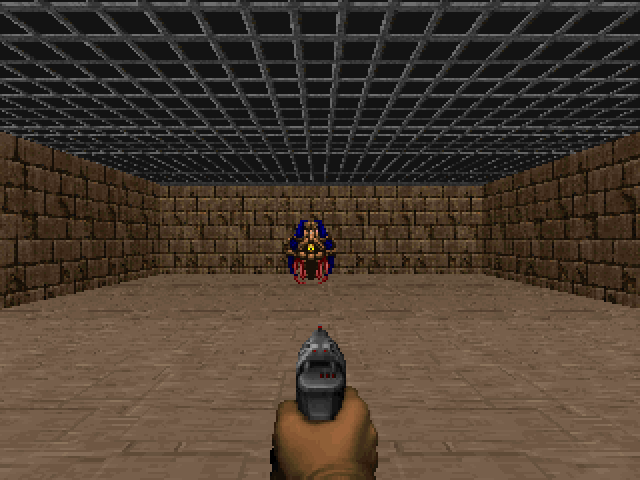

Episode 4: reward=95.00, agent_steps=2, saved=vizdoom_episode_04.gif


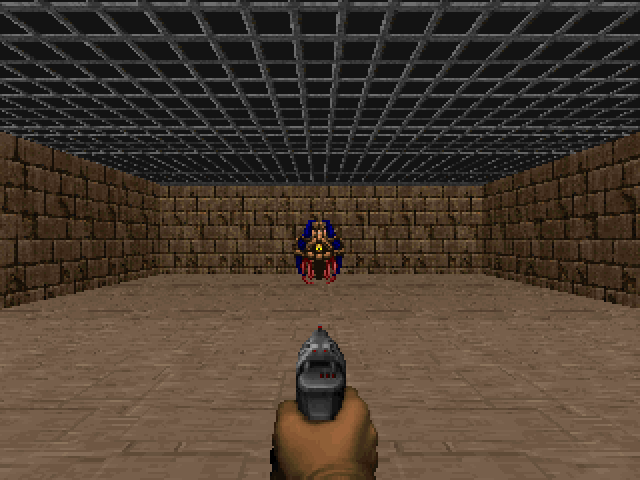

Episode 5: reward=75.00, agent_steps=7, saved=vizdoom_episode_05.gif


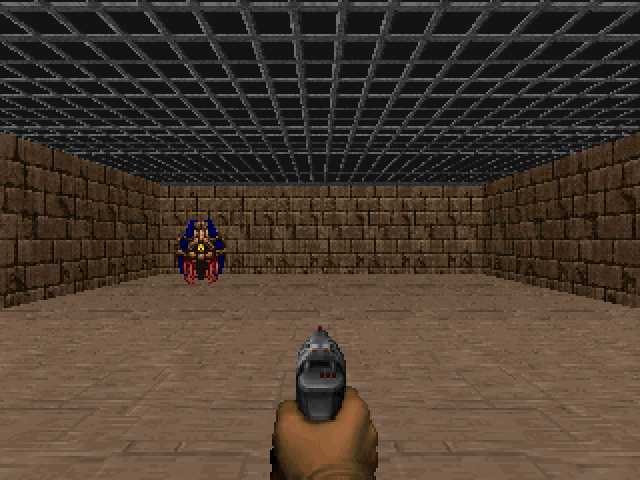

Episode 6: reward=75.00, agent_steps=7, saved=vizdoom_episode_06.gif


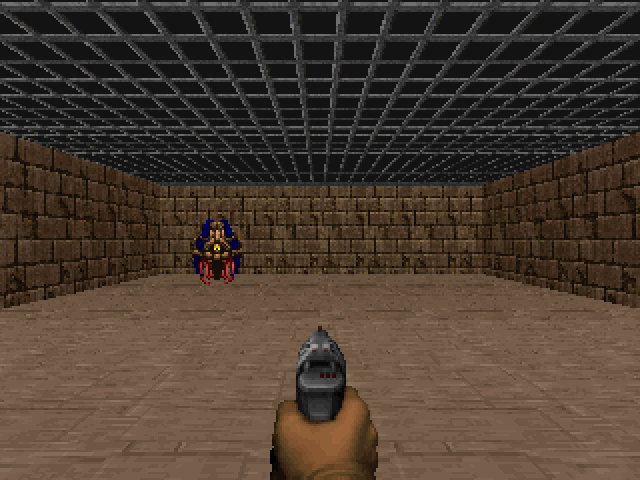

Episode 7: reward=83.00, agent_steps=5, saved=vizdoom_episode_07.gif


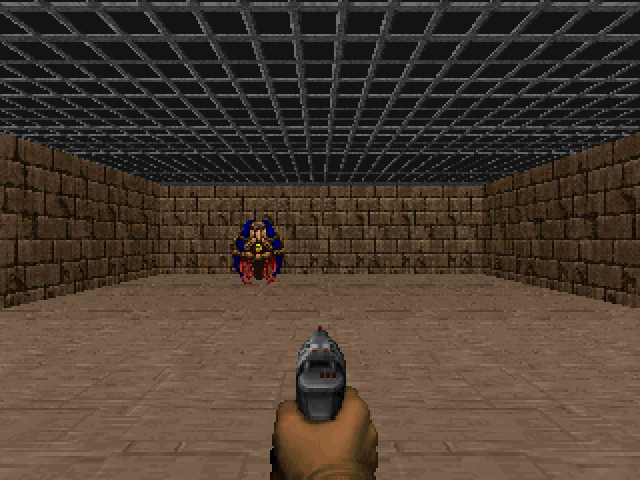

Episode 8: reward=95.00, agent_steps=2, saved=vizdoom_episode_08.gif


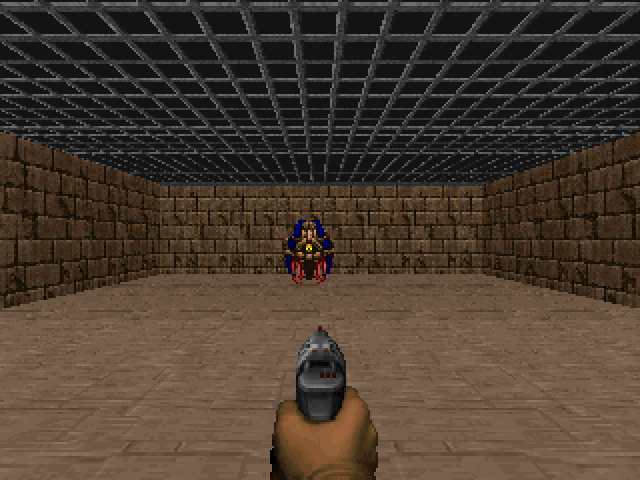

Episode 9: reward=75.00, agent_steps=7, saved=vizdoom_episode_09.gif


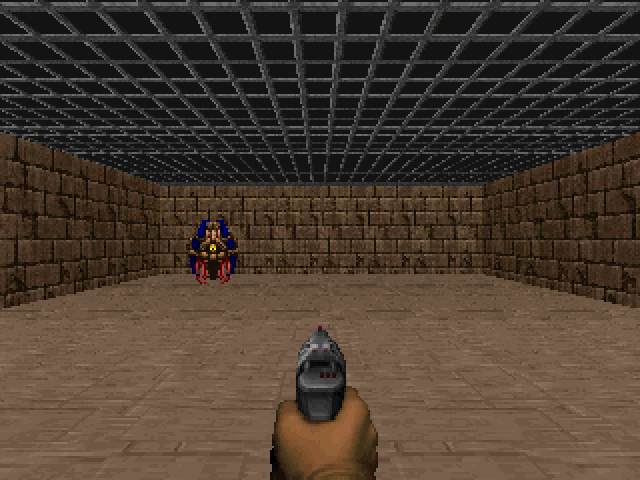

Episode 10: reward=83.00, agent_steps=5, saved=vizdoom_episode_10.gif


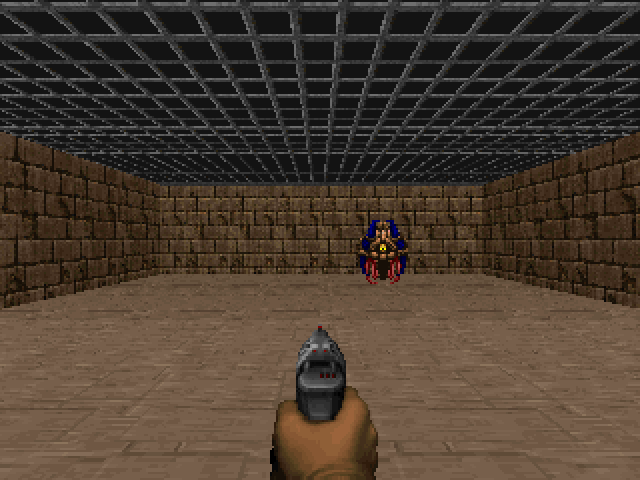

In [ ]:
results = play_and_visualize_colab(
    model_path="./ppo_vizdoom_simple.pt",
    scenario="basic",
    num_episodes=10,
    deterministic=True,  # Select the highest-probability action
    fps=10,
)